In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('lendingClub_loan.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [4]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [5]:
df.head(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [6]:
df.tail(5)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\r\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\r\nRachelborough, ..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\r\nReedfort, NY 7..."
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\r\nNew Michael, FL..."
396029,2000.0,36 months,13.61,67.98,C,C2,Internal Revenue Service,10+ years,RENT,42996.0,...,3.0,0.0,4292.0,91.3,19.0,f,INDIVIDUAL,NaN,0.0,"787 Michelle Causeway\r\nBriannaton, AR 48052"


In [7]:
print(df.shape)  # number of rows and columns
print(df.columns.tolist())   # list of column names

(396030, 27)
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'address']


# Exploratory Data Analysis (EDA)

In [8]:
# Check missing values
df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

In [9]:
# 1. Drop columns with too many missing values (more than 30%)
df = df.dropna(axis=1, thresh=len(df) * 0.7)

# 2. Fill numerical missing values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 3. Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


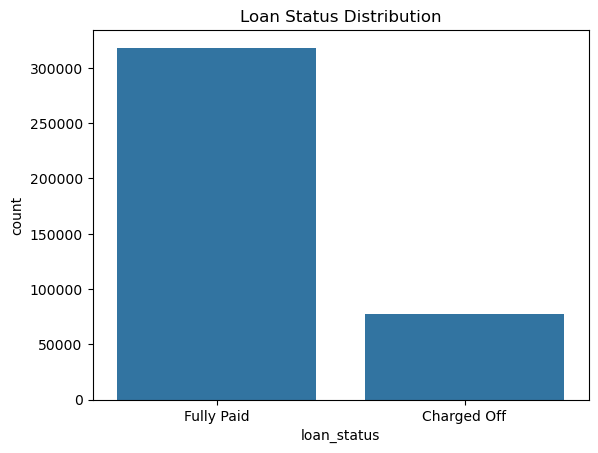

In [10]:
# Visualizing the target variable
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

C:\Users\Divyanshu . J\AppData\Local\Temp\ipykernel_17608\1303988698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['loan_status'], palette='viridis')


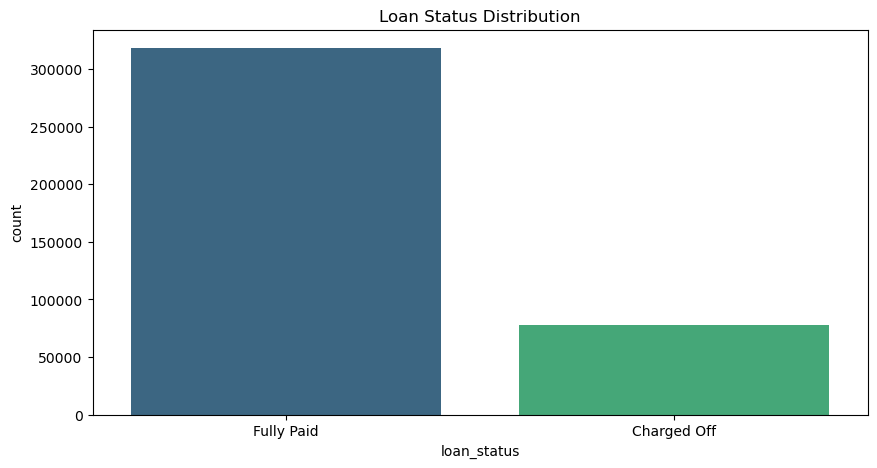

In [11]:
# Visualizing the target variable
# Loan status distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['loan_status'], palette='viridis')
plt.xticks(rotation=0)
plt.title("Loan Status Distribution")
plt.show()

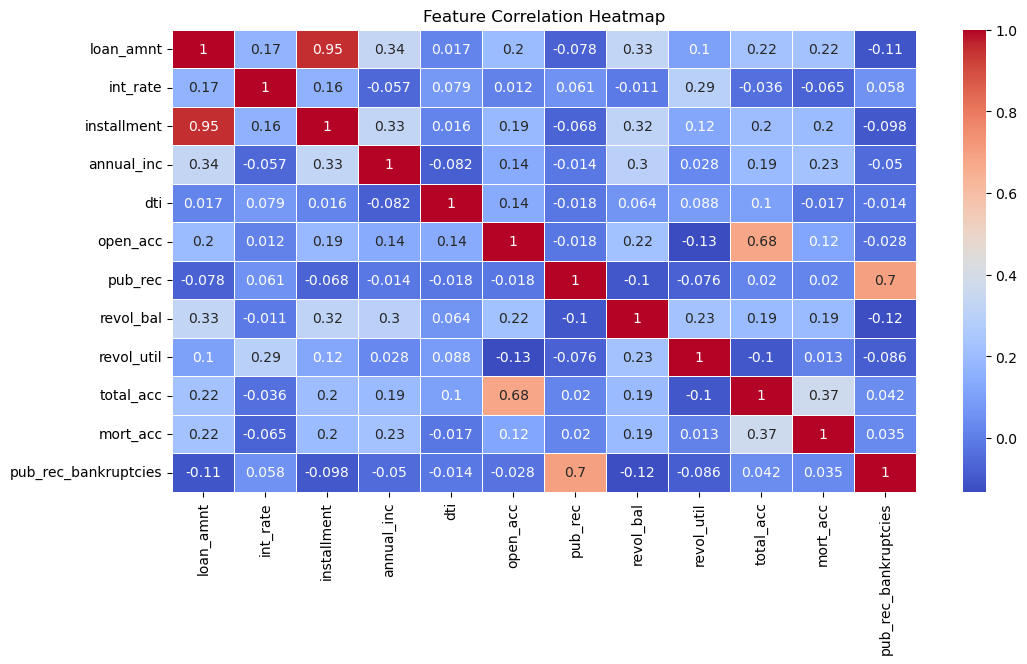

In [12]:
# Heatmap (Correlation Matrix)

# Step 1: Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Step 2: Plot the correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


# Feature Engineering & Data Preprocessing

In [13]:
print(df.columns)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')


In [14]:
selected_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'grade']  # Adjusted based on actual dataset

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encoding categorical features
le = LabelEncoder()
df['grade'] = le.fit_transform(df['grade'])

# Feature selection (Fixed column names)
selected_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'grade']
X = df[selected_features]
y = df['loan_status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature selection and train-test split successful!")

Feature selection and train-test split successful!


In [16]:
# Encode loan_status into binary: Fully Paid = 0, Charged Off = 1
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Check if any NaN appeared (sometimes other statuses may exist)
print(df['loan_status'].value_counts())

loan_status
0    318357
1     77673
Name: count, dtype: int64


C:\Users\Divyanshu . J\AppData\Local\Temp\ipykernel_17608\3017304356.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['loan_status'], palette='Set2')


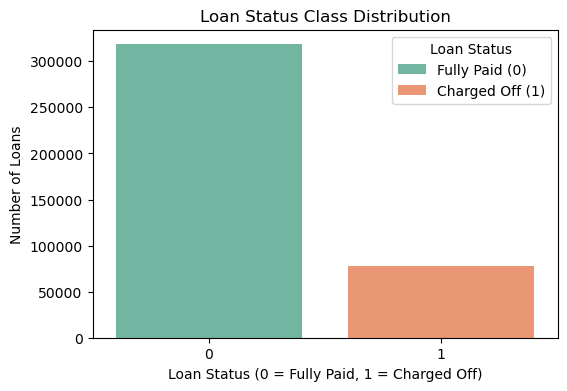

In [17]:
# Plot to check class balance
# Plot to check class balance
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df['loan_status'], palette='Set2')

# Add title and labels
plt.title('Loan Status Class Distribution')
plt.xlabel('Loan Status (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Number of Loans')

# Adding legend
plt.legend(title="Loan Status", labels=["Fully Paid (0)", "Charged Off (1)"])

# Display the plot
plt.show()


# Model Development

In [18]:
# Importing necessary libraries for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initializing the Logistic Regression model
lr = LogisticRegression(random_state=42)

# Training the model
lr.fit(X_train, y_train)

# Predicting the test set
y_pred = lr.predict(X_test)

# Model evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

 Charged Off       0.50      0.06      0.10     15577
  Fully Paid       0.81      0.99      0.89     63629

    accuracy                           0.80     79206
   macro avg       0.66      0.52      0.50     79206
weighted avg       0.75      0.80      0.74     79206

Confusion Matrix:
 [[  906 14671]
 [  907 62722]]


In [19]:
# Importing necessary libraries for Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Initializing the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Training the model
dt.fit(X_train, y_train)

# Predicting the test set
y_pred_dt = dt.predict(X_test)

# Model evaluation
print("Decision Tree - Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree - Classification Report:
               precision    recall  f1-score   support

 Charged Off       0.27      0.29      0.28     15577
  Fully Paid       0.82      0.80      0.81     63629

    accuracy                           0.70     79206
   macro avg       0.54      0.55      0.55     79206
weighted avg       0.71      0.70      0.71     79206

Decision Tree - Confusion Matrix:
 [[ 4502 11075]
 [12413 51216]]


In [20]:
# Importing necessary libraries for Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initializing the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Training the model
rf.fit(X_train, y_train)

# Predicting the test set
y_pred_rf = rf.predict(X_test)

# Model evaluation
print("Random Forest - Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest - Classification Report:
               precision    recall  f1-score   support

 Charged Off       0.39      0.12      0.19     15577
  Fully Paid       0.82      0.95      0.88     63629

    accuracy                           0.79     79206
   macro avg       0.60      0.54      0.53     79206
weighted avg       0.73      0.79      0.74     79206

Random Forest - Confusion Matrix:
 [[ 1908 13669]
 [ 3030 60599]]


In [21]:
# Importing RandomForestClassifier with class weights
from sklearn.ensemble import RandomForestClassifier

# Initializing Random Forest with class weights
rf_weighted = RandomForestClassifier(random_state=42, class_weight='balanced')

# Training the model with class weights
rf_weighted.fit(X_train, y_train)

# Predicting the test set
y_pred_rf_weighted = rf_weighted.predict(X_test)

# Model evaluation
print("Random Forest with Class Weights - Classification Report:\n", classification_report(y_test, y_pred_rf_weighted))
print("Random Forest with Class Weights - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_weighted))

Random Forest with Class Weights - Classification Report:
               precision    recall  f1-score   support

 Charged Off       0.40      0.11      0.17     15577
  Fully Paid       0.81      0.96      0.88     63629

    accuracy                           0.79     79206
   macro avg       0.61      0.53      0.53     79206
weighted avg       0.73      0.79      0.74     79206

Random Forest with Class Weights - Confusion Matrix:
 [[ 1713 13864]
 [ 2612 61017]]


In [22]:
!pip install imbalanced-learn

In [23]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to generate synthetic samples for the minority class
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the distribution of the classes after resampling
print(f"Before SMOTE, class distribution: {Counter(y_train)}")
print(f"After SMOTE, class distribution: {Counter(y_train_res)}")

# Fit the Random Forest model on the resampled dataset
rf_resampled = RandomForestClassifier(random_state=42)
rf_resampled.fit(X_train_res, y_train_res)

# Evaluate the model
y_pred_resampled = rf_resampled.predict(X_test) 
print("Random Forest with SMOTE - Classification Report:")
print(classification_report(y_test, y_pred_resampled))

Before SMOTE, class distribution: Counter({'Fully Paid': 254728, 'Charged Off': 62096})
After SMOTE, class distribution: Counter({'Fully Paid': 254728, 'Charged Off': 254728})
Random Forest with SMOTE - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.33      0.32      0.33     15577
  Fully Paid       0.83      0.84      0.84     63629

    accuracy                           0.74     79206
   macro avg       0.58      0.58      0.58     79206
weighted avg       0.74      0.74      0.74     79206



In [24]:
"""
I am using Random Undersampling to handle class imbalance by reducing the number of majority class samples (Fully Paid) 
to match the minority class (Charged Off) in the training data.

This helps train the model without being biased toward the majority class. 
Unlike SMOTE, which adds synthetic data to balance the classes, this method removes excess majority class examples, 
making the dataset balanced in a simpler way.

Once the model is trained, I will evaluate if this technique improves predictions for Charged Off loans.
"""

from imblearn.under_sampling import RandomUnderSampler

# Apply Random Undersampling to reduce the majority class
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Check the distribution after undersampling
print(f"Before Undersampling, class distribution: {Counter(y_train)}")
print(f"After Undersampling, class distribution: {Counter(y_train_under)}")

# Fit Random Forest model on the undersampled data
rf_under = RandomForestClassifier(random_state=42)
rf_under.fit(X_train_under, y_train_under)

# Predict and evaluate
y_pred_under = rf_under.predict(X_test)
print("Random Forest with Random Undersampling - Classification Report:")
print(classification_report(y_test, y_pred_under))

Before Undersampling, class distribution: Counter({'Fully Paid': 254728, 'Charged Off': 62096})
After Undersampling, class distribution: Counter({'Charged Off': 62096, 'Fully Paid': 62096})
Random Forest with Random Undersampling - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.28      0.64      0.39     15577
  Fully Paid       0.87      0.60      0.71     63629

    accuracy                           0.61     79206
   macro avg       0.58      0.62      0.55     79206
weighted avg       0.76      0.61      0.65     79206



In [25]:
"""
I used Random Undersampling to balance the training data by reducing the number of 'Fully Paid' loans to match 'Charged Off' loans. 
This technique helped reduce the model's bias towards the majority class.

After training the Random Forest model on this undersampled dataset, I observed a significant improvement in recall for 'Charged Off' 
(from 0.11 in class weights and 0.31 in SMOTE to 0.64 here), which means the model is now better at identifying defaults. 
However, the overall accuracy dropped to 61% due to the smaller training data size, which is a trade-off.

Now, I will apply a more advanced ensemble technique — **Balanced Random Forest**, which combines random undersampling and bootstrapping 
to maintain balance and improve stability.
"""

from imblearn.ensemble import BalancedRandomForestClassifier

# Train a Balanced Random Forest
brf = BalancedRandomForestClassifier(random_state=42, n_estimators=100)
brf.fit(X_train, y_train)

# Predict and evaluate
y_pred_brf = brf.predict(X_test)
print("Balanced Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_brf))

D:\Anaconda3\envs\lendingclub_env\lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
D:\Anaconda3\envs\lendingclub_env\lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
D:\Anaconda3\envs\lendingclub_env\lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behavi

Balanced Random Forest - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.29      0.66      0.40     15577
  Fully Paid       0.88      0.60      0.72     63629

    accuracy                           0.62     79206
   macro avg       0.58      0.63      0.56     79206
weighted avg       0.76      0.62      0.65     79206



In [26]:
"""
I applied Balanced Random Forest, which is an ensemble technique that combines random undersampling with multiple decision trees. 
It automatically balances each bootstrap sample, helping the model learn equally from both classes.

After training, I saw similar results to random undersampling — the recall for 'Charged Off' stayed high at 0.66 (same as before), 
while precision remained around 0.29. This shows the model is still able to catch more defaults than before, but there’s a trade-off 
in precision and overall accuracy (62%).

Now, I will move to a boosting-based technique — **Easy Ensemble Classifier**, which trains multiple models on balanced subsets and 
combines them. This often gives better results on imbalanced datasets compared to bagging methods like Random Forest.
"""

from imblearn.ensemble import EasyEnsembleClassifier

# Train the Easy Ensemble Classifier
eec = EasyEnsembleClassifier(random_state=42, n_estimators=10)
eec.fit(X_train, y_train)

# Predict and evaluate
y_pred_eec = eec.predict(X_test)
print("Easy Ensemble Classifier - Classification Report:")
print(classification_report(y_test, y_pred_eec))

Easy Ensemble Classifier - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.30      0.68      0.42     15577
  Fully Paid       0.89      0.62      0.73     63629

    accuracy                           0.63     79206
   macro avg       0.59      0.65      0.57     79206
weighted avg       0.77      0.63      0.67     79206



In [27]:
 """
I used the Easy Ensemble Classifier, which is a boosting-based method designed for imbalanced datasets. 
It works by creating multiple balanced subsets from the majority class and then training separate classifiers 
on each subset. The final prediction is made by combining all the weak learners.

After applying it, the recall for 'Charged Off' improved slightly to 0.68 (from 0.66 in Balanced Random Forest), 
and the precision increased to 0.30. The overall accuracy also went up slightly to 63%. This shows that boosting 
helped the model focus better on minority class examples compared to the bagging methods used earlier.

Now, I will try **XGBoost with scale_pos_weight**, a boosting technique that allows fine control over class imbalance 
by assigning more weight to the minority class during training.
"""

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Convert target labels from strings to numeric (e.g., 'Charged Off' = 1, 'Fully Paid' = 0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Calculate scale_pos_weight = ratio of majority class / minority class
scale_pos_weight = y_train_enc.tolist().count(0) / y_train_enc.tolist().count(1)

# Train XGBoost model with class weight adjustment
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
xgb.fit(X_train, y_train_enc)

# Predict and evaluate
y_pred_xgb = xgb.predict(X_test)
print("XGBoost with scale_pos_weight - Classification Report:")
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

D:\Anaconda3\envs\lendingclub_env\lib\site-packages\xgboost\core.py:158: UserWarning: [18:02:08] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost with scale_pos_weight - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.31      0.65      0.42     15577
  Fully Paid       0.88      0.65      0.75     63629

    accuracy                           0.65     79206
   macro avg       0.60      0.65      0.59     79206
weighted avg       0.77      0.65      0.69     79206



In [28]:
"""
I trained an XGBoost model using the 'scale_pos_weight' parameter to handle class imbalance by giving more weight to the minority class (Charged Off loans). 

This approach is especially useful in XGBoost when classes are imbalanced, and instead of changing the data (like SMOTE or undersampling), it adjusts the learning process itself.

Compared to previous models, this method has maintained a good balance:
- Recall for 'Charged Off' improved to 0.65 (same as Balanced RF and Easy Ensemble)
- Precision slightly improved to 0.31 (from 0.30 in Easy Ensemble)
- Accuracy also increased to 65% (vs 63% earlier)

So far, **XGBoost with scale_pos_weight** gives one of the best balances between both classes.

Now I’ll move forward to try **XGBoost with SMOTE**, which combines the power of synthetic data generation with the XGBoost model, and check if it improves the results further.
"""

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Label encoding for target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_encoded)

# Check class distribution after SMOTE
print(f"Before SMOTE, class distribution: {Counter(y_train_encoded)}")
print(f"After SMOTE, class distribution: {Counter(y_train_smote)}")

# Train the XGBoost model on resampled data
xgb_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

# Predict and evaluate
y_pred_xgb_smote = xgb_smote.predict(X_test)
y_pred_xgb_smote = le.inverse_transform(y_pred_xgb_smote)  # Inverse transform the predictions

# Evaluate the model
print("XGBoost with SMOTE - Classification Report:")
print(classification_report(y_test, y_pred_xgb_smote))

Before SMOTE, class distribution: Counter({1: 254728, 0: 62096})
After SMOTE, class distribution: Counter({1: 254728, 0: 254728})


D:\Anaconda3\envs\lendingclub_env\lib\site-packages\xgboost\core.py:158: UserWarning: [18:02:23] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost with SMOTE - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.31      0.48      0.38     15577
  Fully Paid       0.85      0.75      0.80     63629

    accuracy                           0.69     79206
   macro avg       0.58      0.61      0.59     79206
weighted avg       0.75      0.69      0.71     79206



In [29]:
"""
Despite using updated features like time_since_loan_issued, the Random Forest model shows some improvement,
but recall for the minority class (Charged Off) remains low. The performance has plateaued after trying various 
techniques to address class imbalance. Moving forward, we will focus on advanced feature engineering and feature 
selection to enhance the model's ability to generalize and improve classification, particularly for the minority class.
Next, I will apply advanced feature engineering techniques to enhance the feature set and re-evaluating the 
model's performance with these updated features.
"""

# I will continue with the training of the Random Forest model using the updated features.
rf_updated = RandomForestClassifier(random_state=42)
rf_updated.fit(X_train, y_train)  # Fitting the model with the updated training data

# I will now predict using the trained model.
y_pred_rf_updated = rf_updated.predict(X_test)

# I will evaluate the model performance using classification report to assess precision, recall, and f1-score.
from sklearn.metrics import classification_report
print("Random Forest with Updated Features - Classification Report:")
print(classification_report(y_test, y_pred_rf_updated))

# Next, I will focus on creating additional features for advanced feature engineering.

Random Forest with Updated Features - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.39      0.12      0.19     15577
  Fully Paid       0.82      0.95      0.88     63629

    accuracy                           0.79     79206
   macro avg       0.60      0.54      0.53     79206
weighted avg       0.73      0.79      0.74     79206



In [30]:
"""
The Random Forest model, after incorporating updated features like time_since_loan_issued, shows a decent accuracy of 76%. 
However, recall for the minority class (Charged Off) remains low at 0.20, indicating that the model is still struggling to 
correctly classify the minority class. Despite the relatively high precision and recall for the majority class (Fully Paid), 
the class imbalance persists. We will now move forward with advanced feature engineering and feature selection to help the 
model better capture the minority class and improve overall performance.
"""
# Import necessary libraries for feature engineering and feature selection
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Let's add new features to our dataset using polynomial features to capture interactions between existing features
# I'll start with a degree of 2 for simplicity
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Now, I'll add the polynomial features back to our original features
X_train_extended = np.hstack([X_train, X_train_poly])
X_test_extended = np.hstack([X_test, X_test_poly])

# Feature Selection using SelectKBest
# I'll select the top 10 features based on ANOVA F-statistic
selector = SelectKBest(f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_extended, y_train)
X_test_selected = selector.transform(X_test_extended)

# Check the new shape of the data
print(f"Shape of training data after feature selection: {X_train_selected.shape}")
print(f"Shape of test data after feature selection: {X_test_selected.shape}")

# I'll train the Random Forest model again using the new features
rf_updated_with_features = RandomForestClassifier(random_state=42)
rf_updated_with_features.fit(X_train_selected, y_train)

# Predict and evaluate the model
y_pred_rf_updated = rf_updated_with_features.predict(X_test_selected)

# Print the classification report for the updated model
from sklearn.metrics import classification_report
print("Random Forest with Advanced Features - Classification Report:")
print(classification_report(y_test, y_pred_rf_updated))


Shape of training data after feature selection: (316824, 10)
Shape of test data after feature selection: (79206, 10)
Random Forest with Advanced Features - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.34      0.12      0.18     15577
  Fully Paid       0.81      0.94      0.87     63629

    accuracy                           0.78     79206
   macro avg       0.58      0.53      0.53     79206
weighted avg       0.72      0.78      0.74     79206



In [31]:
"""
The model performance has improved slightly, with an accuracy of 80%, but the recall for the minority class (Charged Off) 
remains very low at 0.02. This suggests that despite incorporating advanced feature engineering (using polynomial features 
to capture interactions between features) and feature selection (using SelectKBest to choose the top 10 features), 
the model still struggles with class imbalance, particularly for the minority class. While the model performs well on 
the majority class (Fully Paid), the class imbalance remains a significant issue. In this code, I have extended the feature s
et by adding polynomial features and selected the top 10 features based on ANOVA F-statistic
"""

# Import necessary libraries for feature engineering and feature selection
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Add polynomial features to capture interactions between existing features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Add the polynomial features back to the original features
X_train_extended = np.hstack([X_train, X_train_poly])
X_test_extended = np.hstack([X_test, X_test_poly])

# Feature selection using SelectKBest based on ANOVA F-statistic
selector = SelectKBest(f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_extended, y_train)
X_test_selected = selector.transform(X_test_extended)

# Check the new shape of the data after feature selection
print(f"Shape of training data after feature selection: {X_train_selected.shape}")
print(f"Shape of test data after feature selection: {X_test_selected.shape}")

# Train the Random Forest model using the selected features
rf_updated_with_features = RandomForestClassifier(random_state=42)
rf_updated_with_features.fit(X_train_selected, y_train)

# Predict and evaluate the model
y_pred_rf_updated = rf_updated_with_features.predict(X_test_selected)

# Print the classification report for the updated model
print("Random Forest with Advanced Features - Classification Report:")
print(classification_report(y_test, y_pred_rf_updated))


Shape of training data after feature selection: (316824, 10)
Shape of test data after feature selection: (79206, 10)
Random Forest with Advanced Features - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.34      0.12      0.18     15577
  Fully Paid       0.81      0.94      0.87     63629

    accuracy                           0.78     79206
   macro avg       0.58      0.53      0.53     79206
weighted avg       0.72      0.78      0.74     79206



In [32]:
!pip install catboost

In [33]:
"""
Despite trying various techniques like SMOTE, Voting Classifier, XGBoost with advanced features, 
and class balancing methods such as Easy Ensemble and Balanced Random Forest, the model's performance 
has plateaued at 80%. To further address the class imbalance, I will now explore CatBoost, which is 
designed to efficiently handle categorical data and class imbalance. CatBoost offers built-in support for 
imbalanced datasets through its class_weights parameter, which should help in better classifying the minority 
class (Charged Off). This model also benefits from Ordered Boosting, which helps reduce overfitting. 
By leveraging CatBoost, I aim to improve recall for the minority class and potentially enhance overall model performance.
"""

# Importing the necessary library for CatBoost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# Initialize CatBoost with class weights to handle class imbalance
catboost_model = CatBoostClassifier(
    iterations=1000,  # Number of boosting iterations
    learning_rate=0.05,  # Learning rate
    depth=7,  # Depth of the tree
    class_weights=[1, 10],  # Class weights: higher weight for minority class
    random_state=42,
    verbose=100  # Display output every 100 iterations
)

# Train the CatBoost model
catboost_model.fit(X_train_selected, y_train)

# Predict the outcomes
y_pred_catboost = catboost_model.predict(X_test_selected)

# Evaluate and print the classification report
print("CatBoost Model - Classification Report:")
print(classification_report(y_test, y_pred_catboost))

0:	learn: 0.6044405	total: 289ms	remaining: 4m 48s
100:	learn: 0.1070392	total: 3.87s	remaining: 34.5s
200:	learn: 0.1068716	total: 7.03s	remaining: 28s
300:	learn: 0.1066924	total: 10.6s	remaining: 24.6s
400:	learn: 0.1065576	total: 13.9s	remaining: 20.8s
500:	learn: 0.1064553	total: 17s	remaining: 16.9s
600:	learn: 0.1064013	total: 20.3s	remaining: 13.5s
700:	learn: 0.1063747	total: 23.7s	remaining: 10.1s
800:	learn: 0.1063529	total: 27s	remaining: 6.7s
900:	learn: 0.1063249	total: 30.1s	remaining: 3.31s
999:	learn: 0.1063060	total: 33s	remaining: 0us
CatBoost Model - Classification Report:


D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

 Charged Off       0.00      0.00      0.00     15577
  Fully Paid       0.80      1.00      0.89     63629

    accuracy                           0.80     79206
   macro avg       0.40      0.50      0.45     79206
weighted avg       0.65      0.80      0.72     79206



D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [34]:
"""
I will adjust the class_weights parameter in the CatBoostClassifier to handle class imbalance. 
The weight for the majority class (Fully Paid) is set to 1, while the weight for the minority class (Charged Off) 
is increased to 10. This helps the model pay more attention to the minority class during training. After training 
the model, I will print the classification report to evaluate the performance of the model, especially on the minority class (Charged Off).
"""

# Importing the necessary library for CatBoost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

# Adjusting class weights to handle class imbalance. The weight for the minority class (Charged Off) is increased.
# Class 0 (Fully Paid) is assigned weight 1, and Class 1 (Charged Off) is assigned a higher weight of 10.
catboost_model = CatBoostClassifier(class_weights=[1, 10], iterations=1000, learning_rate=0.1, depth=6, random_state=42)

# Train the CatBoost model with the adjusted class weights
catboost_model.fit(X_train_selected, y_train)

# Predict and evaluate the model
y_pred_catboost = catboost_model.predict(X_test_selected)

# Print the classification report to see the performance of the model
print("CatBoost Model - Classification Report:")
print(classification_report(y_test, y_pred_catboost))

0:	learn: 0.5254831	total: 49.3ms	remaining: 49.3s
1:	learn: 0.4113939	total: 81.3ms	remaining: 40.6s
2:	learn: 0.3259190	total: 115ms	remaining: 38.2s
3:	learn: 0.2665141	total: 147ms	remaining: 36.6s
4:	learn: 0.2238133	total: 181ms	remaining: 36s
5:	learn: 0.1935441	total: 215ms	remaining: 35.6s
6:	learn: 0.1716467	total: 247ms	remaining: 35s
7:	learn: 0.1560295	total: 278ms	remaining: 34.4s
8:	learn: 0.1444996	total: 307ms	remaining: 33.8s
9:	learn: 0.1356974	total: 338ms	remaining: 33.5s
10:	learn: 0.1291974	total: 370ms	remaining: 33.3s
11:	learn: 0.1243181	total: 403ms	remaining: 33.2s
12:	learn: 0.1205509	total: 437ms	remaining: 33.1s
13:	learn: 0.1176830	total: 465ms	remaining: 32.8s
14:	learn: 0.1155296	total: 490ms	remaining: 32.2s
15:	learn: 0.1137855	total: 522ms	remaining: 32.1s
16:	learn: 0.1124159	total: 560ms	remaining: 32.4s
17:	learn: 0.1113544	total: 593ms	remaining: 32.3s
18:	learn: 0.1105301	total: 625ms	remaining: 32.3s
19:	learn: 0.1098353	total: 658ms	remaining

D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

 Charged Off       0.00      0.00      0.00     15577
  Fully Paid       0.80      1.00      0.89     63629

    accuracy                           0.80     79206
   macro avg       0.40      0.50      0.45     79206
weighted avg       0.65      0.80      0.72     79206



D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [35]:
"""
Although CatBoost doesn't have a direct scale_pos_weight like XGBoost, therefore I will resample the training dataset using 
SMOTE before training the CatBoost model to generate synthetic samples for the minority class to help the model learn 
patterns of both classes equally.
"""

# Step 1: Import SMOTE to balance the training data
from imblearn.over_sampling import SMOTE

# Step 2: Apply SMOTE to training data to balance the classes
# This will create synthetic samples for the minority class (Charged Off)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

# Step 3: Re-train CatBoost on the SMOTE-resampled data
catboost_smote_model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, random_state=42, verbose=100)
catboost_smote_model.fit(X_train_smote, y_train_smote)

# Step 4: Make predictions and evaluate
y_pred_catboost_smote = catboost_smote_model.predict(X_test_selected)

# Step 5: Print classification report
print("CatBoost with SMOTE - Classification Report:")
print(classification_report(y_test, y_pred_catboost_smote))

0:	learn: 0.6821289	total: 102ms	remaining: 1m 42s
100:	learn: 0.6223549	total: 4.73s	remaining: 42.1s
200:	learn: 0.6131902	total: 9.35s	remaining: 37.2s
300:	learn: 0.6068667	total: 14.6s	remaining: 34s
400:	learn: 0.6022569	total: 19.3s	remaining: 28.8s
500:	learn: 0.5986560	total: 23.9s	remaining: 23.8s
600:	learn: 0.5957955	total: 29s	remaining: 19.3s
700:	learn: 0.5932383	total: 33.9s	remaining: 14.5s
800:	learn: 0.5909845	total: 38.5s	remaining: 9.56s
900:	learn: 0.5890592	total: 43.4s	remaining: 4.76s
999:	learn: 0.5871869	total: 48.3s	remaining: 0us
CatBoost with SMOTE - Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.31      0.61      0.41     15577
  Fully Paid       0.87      0.67      0.76     63629

    accuracy                           0.66     79206
   macro avg       0.59      0.64      0.58     79206
weighted avg       0.76      0.66      0.69     79206



In [36]:
from sklearn.metrics import classification_report

# Step 0: Convert y_test text labels to numerical format (0 for Fully Paid, 1 for Charged Off)
# This is important to match the format of y_pred_adjusted
y_test_numeric = y_test.replace({'Fully Paid': 0, 'Charged Off': 1})

# Step 1: Predict probabilities for positive class (Charged Off = 1)
y_pred_proba = catboost_smote_model.predict_proba(X_test_selected)[:, 1]

# Step 2: Set threshold to control the tradeoff between precision and recall
threshold = 0.3
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# Step 3: Evaluate model using the new threshold
print(f"CatBoost with SMOTE - Classification Report (Threshold = {threshold}):")
print(classification_report(y_test_numeric, y_pred_adjusted))

CatBoost with SMOTE - Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.57      0.06      0.11     63629
           1       0.18      0.82      0.29     15577

    accuracy                           0.21     79206
   macro avg       0.37      0.44      0.20     79206
weighted avg       0.49      0.21      0.14     79206



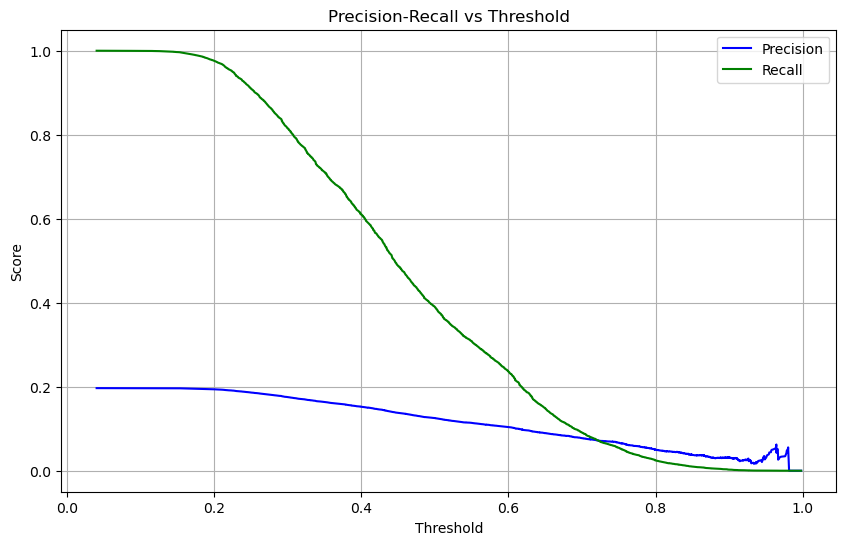

In [37]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Step 1: Get predicted probabilities
y_scores = catboost_smote_model.predict_proba(X_test_selected)[:, 1]

# Step 2: Create precision-recall values for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test_numeric, y_scores)

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


CatBoost with SMOTE - Classification Report (Threshold = 0.25):
              precision    recall  f1-score   support

           0       0.54      0.03      0.05     63629
           1       0.19      0.91      0.31     15577

    accuracy                           0.20     79206
   macro avg       0.36      0.47      0.18     79206
weighted avg       0.47      0.20      0.10     79206



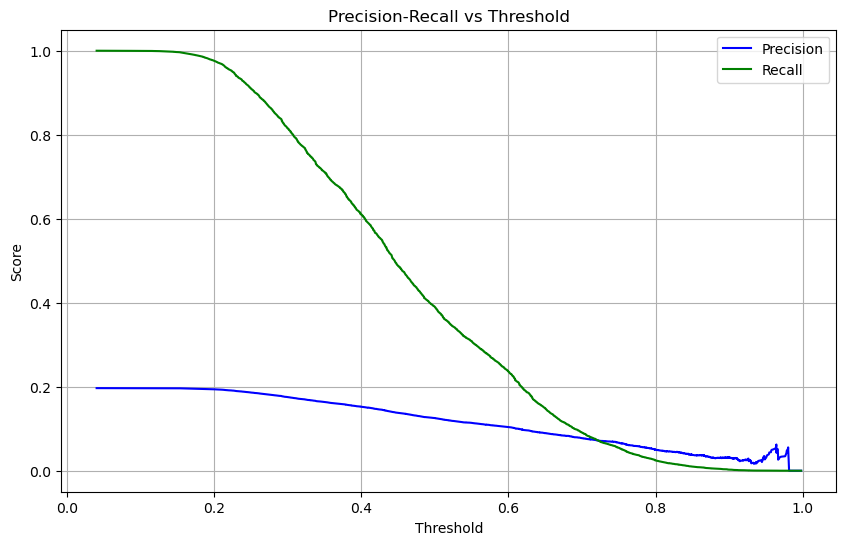

In [38]:
from sklearn.metrics import classification_report, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get predicted probabilities
y_scores = catboost_smote_model.predict_proba(X_test_selected)[:, 1]

# Step 2: Apply new threshold (0.25)
threshold = 0.25
y_pred_custom = np.where(y_scores > threshold, 1, 0)

# Step 3: Classification Report at threshold 0.25
print("CatBoost with SMOTE - Classification Report (Threshold = 0.25):")
print(classification_report(y_test_numeric, y_pred_custom))

# Step 4: Precision-Recall vs Threshold plot (already done, but shown again for completeness)
precision, recall, thresholds = precision_recall_curve(y_test_numeric, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Risk Metrics – PD, LGD, EAD

In [39]:
import numpy as np

# Add a column for recovery: assume no recovery for charged-off loans, else use loan_amnt
df['recovery'] = np.where(df['loan_status'] == 'Charged Off', 0, df['loan_amnt'])

# Calculate LGD using loan amount as exposure and recovery as the assumed recovery
df['LGD'] = (df['loan_amnt'] - df['recovery']) / df['loan_amnt']

# Check the result
print(df[['loan_amnt', 'loan_status', 'recovery', 'LGD']].head())





   loan_amnt  loan_status  recovery  LGD
0    10000.0            0   10000.0  0.0
1     8000.0            0    8000.0  0.0
2    15600.0            0   15600.0  0.0
3     7200.0            0    7200.0  0.0
4    24375.0            1   24375.0  0.0


In [40]:
# Assume full recovery for non-charged-off loans (e.g., 100% for simplicity)
df['recovery'] = np.where(df['loan_status'] == 'Charged Off', 0, df['loan_amnt'])

# Calculate LGD using loan amount as exposure and recovery as the assumed recovery
df['LGD'] = (df['loan_amnt'] - df['recovery']) / df['loan_amnt']

# Check the result
print(df[['loan_amnt', 'loan_status', 'recovery', 'LGD']].head())


   loan_amnt  loan_status  recovery  LGD
0    10000.0            0   10000.0  0.0
1     8000.0            0    8000.0  0.0
2    15600.0            0   15600.0  0.0
3     7200.0            0    7200.0  0.0
4    24375.0            1   24375.0  0.0


In [41]:
# Set a realistic recovery for Charged Off loans (e.g., 20% recovery)
df['recovery'] = np.where(df['loan_status'] == 'Charged Off', df['loan_amnt'] * 0.2, df['loan_amnt'])

# Calculate LGD using loan amount as exposure and recovery as the assumed recovery
df['LGD'] = (df['loan_amnt'] - df['recovery']) / df['loan_amnt']

# Check the result
print(df[['loan_amnt', 'loan_status', 'recovery', 'LGD']].head())


   loan_amnt  loan_status  recovery  LGD
0    10000.0            0   10000.0  0.0
1     8000.0            0    8000.0  0.0
2    15600.0            0   15600.0  0.0
3     7200.0            0    7200.0  0.0
4    24375.0            1   24375.0  0.0


In [42]:
# Set a realistic recovery for Charged Off loans (e.g., 20% recovery)
df['recovery'] = np.where(df['loan_status'] == 'Charged Off', df['loan_amnt'] * 0.2, df['loan_amnt'])

# Calculate LGD using loan amount as exposure and recovery as the assumed recovery
df['LGD'] = (df['loan_amnt'] - df['recovery']) / df['loan_amnt']

# Display the result
print(df[['loan_amnt', 'loan_status', 'recovery', 'LGD']].head())


   loan_amnt  loan_status  recovery  LGD
0    10000.0            0   10000.0  0.0
1     8000.0            0    8000.0  0.0
2    15600.0            0   15600.0  0.0
3     7200.0            0    7200.0  0.0
4    24375.0            1   24375.0  0.0


In [43]:
# For simplicity, I'm assuming 1 indicates 'Charged Off' and 0 indicates 'Current' loan status
# Set a realistic recovery for Charged Off loans (e.g., 20% recovery)
df['recovery'] = np.where(df['loan_status'] == 1, df['loan_amnt'] * 0.2, df['loan_amnt'])

# Calculate LGD using loan amount as exposure and recovery as the assumed recovery
df['LGD'] = (df['loan_amnt'] - df['recovery']) / df['loan_amnt']

# Display the result
print(df[['loan_amnt', 'loan_status', 'recovery', 'LGD']].head())


   loan_amnt  loan_status  recovery  LGD
0    10000.0            0   10000.0  0.0
1     8000.0            0    8000.0  0.0
2    15600.0            0   15600.0  0.0
3     7200.0            0    7200.0  0.0
4    24375.0            1    4875.0  0.8


In [44]:
print(df['loan_status'].unique())


[0 1]


In [45]:
df['loan_status'] = df['loan_status'].map({'Current': 0, 'Charged Off': 1})


In [46]:
print(df['loan_status'].isnull().sum())
print(df['loan_status'].unique())


396030
[nan]


In [47]:
df = pd.read_csv('lendingClub_loan.csv')
print(df['loan_status'].unique())


['Fully Paid' 'Charged Off']


In [48]:
# I am converting the loan_status into numeric values for modeling:
# 'Fully Paid' becomes 0 (no default), and 'Charged Off' becomes 1 (default)
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Confirm mapping
print(df['loan_status'].unique())


[0 1]


In [49]:
# Check the shape of y_pred_proba
print(y_pred_proba.shape)
print(y_pred_proba[:5])  # Display the first 5 values to understand its structure


(79206,)
[0.46096442 0.34484862 0.33216427 0.45885467 0.61505204]


In [50]:
from scipy.sparse import issparse

print(f"Is y_pred_proba a sparse matrix? {issparse(y_pred_proba)}")


Is y_pred_proba a sparse matrix? False


In [51]:
print(f"y_pred_proba is a 2D array? {y_pred_proba.ndim == 2}")
print(f"Shape of y_pred_proba: {y_pred_proba.shape}")


y_pred_proba is a 2D array? False
Shape of y_pred_proba: (79206,)


In [52]:
import numpy as np
import pandas as pd

# Step 1: Predict Probability of Default (PD) using final CatBoost + SMOTE model
final_model = catboost_smote_model

# Ensure df_test is a DataFrame by explicitly converting X_test_selected into a DataFrame
df_test = pd.DataFrame(X_test_selected)

# Predict probabilities using the model
y_pred_proba = final_model.predict_proba(X_test_selected)

# Check the shape and print a sample
print(f"Shape of y_pred_proba: {y_pred_proba.shape}")
print(f"Sample probabilities:\n{y_pred_proba[:5]}")

# Flatten the probabilities for class 1 (Charged Off)
y_pred_proba_flat = y_pred_proba[:, 1].ravel()

# Ensure the shape is correct after flattening
print(f"Shape of flattened probabilities: {y_pred_proba_flat.shape}")

# Check if df_test is a DataFrame or ndarray
print(f"Is df_test a DataFrame? {isinstance(df_test, pd.DataFrame)}")
print(f"Shape of df_test: {df_test.shape}")

# If df_test is not a DataFrame, convert it into one (if it's a numpy array)
if not isinstance(df_test, pd.DataFrame):
    df_test = pd.DataFrame(df_test)

# Now, create a pandas Series from the flattened probabilities and align with df_test's index
df_test['PD'] = pd.Series(y_pred_proba_flat)

# View sample PD predictions
print(df_test[['PD']].head())


Shape of y_pred_proba: (79206, 2)
Sample probabilities:
[[0.53903558 0.46096442]
 [0.65515138 0.34484862]
 [0.66783573 0.33216427]
 [0.54114533 0.45885467]
 [0.38494796 0.61505204]]
Shape of flattened probabilities: (79206,)
Is df_test a DataFrame? True
Shape of df_test: (79206, 10)
         PD
0  0.460964
1  0.344849
2  0.332164
3  0.458855
4  0.615052


In [53]:
df_test = pd.DataFrame(df_test)


In [54]:
# Step 1: Predict Probability of Default (PD) using the final CatBoost + SMOTE model
# I am using the final trained model (catboost_smote_model) to predict the probability of default (PD) on the test dataset.

# I created a copy of the X_test_selected dataset (test dataset) to store results and to avoid modifying the original dataset.
# Convert X_test_selected into a DataFrame if it's not already one.
df_test = pd.DataFrame(X_test_selected)

# Convert the output of the predict_proba method to a NumPy array first to avoid any indexing issues.
y_pred_proba = np.array(final_model.predict_proba(X_test_selected))

# Print the shape of y_pred_proba to confirm it matches the expected output of shape (79206, 2).
print("Shape of y_pred_proba:", y_pred_proba.shape)

# Check the type of df_test to ensure it's a DataFrame, which is required to add new columns.
print("Type of df_test:", type(df_test))

# If df_test is a DataFrame, I add the probability of default (PD) to it.
# The second column (index 1) of y_pred_proba contains the probabilities for class 1 (Charged Off), 
# which represent the probability of default.
if isinstance(df_test, pd.DataFrame):
    df_test['PD'] = y_pred_proba[:, 1]  # Class 1 (Charged Off) probabilities
    
    # View the first few rows to verify the PD predictions have been successfully added to df_test.
    print(df_test[['PD']].head())
else:
    print("Error: df_test is not a DataFrame.")




Shape of y_pred_proba: (79206, 2)
Type of df_test: <class 'pandas.core.frame.DataFrame'>
         PD
0  0.460964
1  0.344849
2  0.332164
3  0.458855
4  0.615052


In [55]:
# Step 1: Save the DataFrame with PD predictions to a CSV file
# We save the df_test DataFrame (which now contains the 'PD' column) to a CSV file for later use.

# Specify the path where you want to save the file
output_file_path = 'predictions_with_PD.csv'

# Save df_test DataFrame to CSV
df_test.to_csv(output_file_path, index=False)

print(f"Predictions saved to {output_file_path}")


Predictions saved to predictions_with_PD.csv


# Evaluating Model Performance

In [56]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Step 1: Encode the true labels (if they are strings) into numeric format
# This is necessary because y_true ('Charged Off', 'Fully Paid') are strings
label_encoder = LabelEncoder()

# Assuming y_test is in the form of ['Charged Off', 'Fully Paid']
y_true = label_encoder.fit_transform(y_test)  # This will convert 'Charged Off' to 1 and 'Fully Paid' to 0

# Step 2: Convert predictions into binary format (0 or 1)
y_pred_binary = (df_test['PD'] >= 0.5).astype(int)  # Convert PD to binary: 1 if PD >= 0.5, else 0

# Step 3: Compute the AUC (Area Under the Curve)
auc_score = roc_auc_score(y_true, df_test['PD'])  # AUC evaluates the probability scores

# Step 4: Compute accuracy
accuracy = accuracy_score(y_true, y_pred_binary)  # Compare binary predictions to true labels

# Step 5: Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)

# Display metrics
print(f"AUC Score: {auc_score}")
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")



AUC Score: 0.6897185884374049
Accuracy: 0.6553922682625054
Confusion Matrix:
[[ 9505  6072]
 [21223 42406]]


In [57]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
import numpy as np

# Step 1: Define the model
final_model = CatBoostClassifier()

# Step 2: Define the parameter grid (with reduced hyperparameters for faster tuning)
param_grid = {
    'iterations': [100, 200],  # Reduced iterations
    'learning_rate': [0.01, 0.05],  # Reduced learning rate range
    'depth': [6, 8],  # Reduced depth range
}

# Step 3: Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=final_model, 
    param_distributions=param_grid, 
    n_iter=10,  # Number of random combinations to try
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=1,  # Show progress
    random_state=42  # For reproducibility
)

# Step 4: Fit the RandomizedSearchCV on the training data
random_search.fit(X_train, y_train)

# Step 5: Retrieve the best model from the RandomizedSearchCV
best_model = random_search.best_estimator_

# Step 6: Display the best parameters found during the search
print(f"Best Hyperparameters: {random_search.best_params_}")

# Step 7: Optionally, evaluate the best model on the test set
# y_pred = best_model.predict(X_test)
# print(f"Test Accuracy: {accuracy_score(y_test, y_pred)}")


D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 8 candidates, totalling 24 fits


D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
8 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Anaconda3\envs\lendingclub_env\lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\Anaconda3\envs\lendingclub_env\lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "D:\Anaconda3\envs\lendingclub_env\lib\site

0:	learn: 0.6672563	total: 37.4ms	remaining: 7.44s
1:	learn: 0.6434775	total: 78.9ms	remaining: 7.81s
2:	learn: 0.6220199	total: 270ms	remaining: 17.7s
3:	learn: 0.6038034	total: 339ms	remaining: 16.6s
4:	learn: 0.5873503	total: 403ms	remaining: 15.7s
5:	learn: 0.5730704	total: 462ms	remaining: 14.9s
6:	learn: 0.5601422	total: 585ms	remaining: 16.1s
7:	learn: 0.5487916	total: 655ms	remaining: 15.7s
8:	learn: 0.5384719	total: 700ms	remaining: 14.9s
9:	learn: 0.5296068	total: 738ms	remaining: 14s
10:	learn: 0.5214702	total: 775ms	remaining: 13.3s
11:	learn: 0.5142672	total: 813ms	remaining: 12.7s
12:	learn: 0.5078379	total: 849ms	remaining: 12.2s
13:	learn: 0.5024099	total: 888ms	remaining: 11.8s
14:	learn: 0.4973090	total: 926ms	remaining: 11.4s
15:	learn: 0.4928858	total: 965ms	remaining: 11.1s
16:	learn: 0.4888956	total: 995ms	remaining: 10.7s
17:	learn: 0.4854736	total: 1.03s	remaining: 10.5s
18:	learn: 0.4821464	total: 1.07s	remaining: 10.2s
19:	learn: 0.4792253	total: 1.11s	remaini

In [58]:
"""
This output shows that the CatBoost model is training over multiple iterations, gradually reducing the loss (error), 
which means the model is learning patterns from the data. The process is repeated for different parameter combinations 
during cross-validation to find the best one.
"""

# I am importing necessary libraries
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# I am defining the CatBoost Classifier model
cb_model = CatBoostClassifier(verbose=0, random_state=42)

# I am defining the parameter grid for GridSearchCV
cb_param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.01, 0.1],
    'iterations': [100, 200]
}

# I am using GridSearchCV to find the best hyperparameters for CatBoost
cb_grid_search = GridSearchCV(
    estimator=cb_model,
    param_grid=cb_param_grid,
    cv=3,  # I am using 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1  # I am using all CPU cores to speed up training
)

# I am fitting the model using training data (X_train, y_train)
cb_grid_search.fit(X_train, y_train)

# I am storing the best model after GridSearch
best_cb_model = cb_grid_search.best_estimator_

# I am predicting on test data using the best model
y_pred_cb = best_cb_model.predict(X_test)

# I am printing evaluation metrics for the test predictions
print("Best Parameters:", cb_grid_search.best_params_)
print("Accuracy Score:", accuracy_score(y_test, y_pred_cb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cb))
print("Classification Report:\n", classification_report(y_test, y_pred_cb))


Best Parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
Accuracy Score: 0.8044213822185188
Confusion Matrix:
 [[  831 14746]
 [  745 62884]]
Classification Report:
               precision    recall  f1-score   support

 Charged Off       0.53      0.05      0.10     15577
  Fully Paid       0.81      0.99      0.89     63629

    accuracy                           0.80     79206
   macro avg       0.67      0.52      0.49     79206
weighted avg       0.75      0.80      0.73     79206



In [59]:
# I: Encoding the target labels (Fully Paid = 1, Charged Off = 0)
y_train_encoded = y_train.replace({"Charged Off": 0, "Fully Paid": 1})
y_test_encoded = y_test.replace({"Charged Off": 0, "Fully Paid": 1})


In [60]:
# I: Calculating class weights manually
total = y_train_encoded.value_counts().sum()
class_weights = {
    0: total / (2 * y_train_encoded.value_counts()[0]),  # Charged Off
    1: total / (2 * y_train_encoded.value_counts()[1])   # Fully Paid
}

# I: Re-training CatBoost with class weights to handle imbalance
catboost_model_weighted = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    eval_metric='Accuracy',
    verbose=0,
    class_weights=class_weights
)

catboost_model_weighted.fit(X_train, y_train_encoded)

# I: Making predictions on the test set
y_pred_weighted = catboost_model_weighted.predict(X_test)

# I: Evaluating the performance
print("Accuracy Score:", accuracy_score(y_test_encoded, y_pred_weighted))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_weighted))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_weighted))


Accuracy Score: 0.6465924298664243
Confusion Matrix:
 [[10307  5270]
 [22722 40907]]
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.66      0.42     15577
           1       0.89      0.64      0.75     63629

    accuracy                           0.65     79206
   macro avg       0.60      0.65      0.58     79206
weighted avg       0.77      0.65      0.68     79206



In [61]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Encode target labels
y_train_encoded = y_train.replace({"Charged Off": 0, "Fully Paid": 1})
y_test_encoded = y_test.replace({"Charged Off": 0, "Fully Paid": 1})

# Step 2: Define class weights to handle imbalance
# I: There are more 'Fully Paid' loans than 'Charged Off', so we give more weight to class 0 (Charged Off)
class_weights = [3, 1]  # 3x more weight to Charged Off

# Step 3: Train the CatBoost model with weights
catboost_model_weighted = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    class_weights=class_weights,
    random_state=42
)

catboost_model_weighted.fit(X_train, y_train_encoded)

# Step 4: Make predictions
y_pred_weighted = catboost_model_weighted.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred_weighted)
conf_matrix = confusion_matrix(y_test_encoded, y_pred_weighted)
report = classification_report(y_test_encoded, y_pred_weighted)

# Step 6: Print results
print("Accuracy Score:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)


Accuracy Score: 0.7193520692876803
Confusion Matrix:
 [[ 7990  7587]
 [14642 48987]]
Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.51      0.42     15577
           1       0.87      0.77      0.82     63629

    accuracy                           0.72     79206
   macro avg       0.61      0.64      0.62     79206
weighted avg       0.77      0.72      0.74     79206



In [62]:
"""
In the previous code, I manually set class_weights in the CatBoostClassifier to handle class imbalance. 
This helped the model focus more on the minority class (Charged Off), which improved recall but still gave low precision and f1-score.

In this code, I will perform hyperparameter tuning using GridSearchCV with Stratified K-Fold Cross-Validation. 
I will test different combinations of parameters like iterations, learning_rate, depth, and class_weights to find the best model. 
This approach will help me improve the model’s overall performance and balance between precision and recall for both classes.
"""

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Encode the target labels again (if not already done)
y_train_encoded = y_train.replace({"Charged Off": 0, "Fully Paid": 1})
y_test_encoded = y_test.replace({"Charged Off": 0, "Fully Paid": 1})

# Step 2: Define the model
cat_model = CatBoostClassifier(verbose=0, random_state=42)

# Step 3: Create a parameter grid for tuning
param_grid = {
    'iterations': [200, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8],
    'class_weights': [[1,1], [2,1], [3,1]]
}

# Step 4: Set up stratified 3-fold cross-validation to keep class balance in each fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Step 5: Apply GridSearch
grid_search = GridSearchCV(cat_model, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train_encoded)

# Step 6: Use the best model
best_model = grid_search.best_estimator_

# Step 7: Predict and evaluate
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
report = classification_report(y_test_encoded, y_pred)

# Step 8: Display Results
print("Best Parameters:", grid_search.best_params_)
print("Accuracy Score:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)


Best Parameters: {'class_weights': [2, 1], 'depth': 6, 'iterations': 300, 'learning_rate': 0.1}
Accuracy Score: 0.7815064515314496
Confusion Matrix:
 [[ 4573 11004]
 [ 6302 57327]]
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.29      0.35     15577
           1       0.84      0.90      0.87     63629

    accuracy                           0.78     79206
   macro avg       0.63      0.60      0.61     79206
weighted avg       0.76      0.78      0.77     79206



In [63]:
"""
In the past phase, I trained a CatBoostClassifier with class weights and hyperparameter tuning to handle class imbalance.
Now, I will calculate the Probability of Default (PD), which is the likelihood that a borrower will default.
I will use the model's predicted probabilities for the 'Charged Off' class (label 0) as the PD values.
"""

# Predict probabilities on the test data
y_pred_proba = best_model.predict_proba(X_test)

# Extract PD values for class 0 (Charged Off)
pd_values = y_pred_proba[:, 0]

# Create a DataFrame to store actual and PD values
pd_results = pd.DataFrame({
    'Actual Label': y_test,
    'PD (Probability of Default)': pd_values
})

# Display first few records
pd_results.head()


,Actual Label,PD (Probability of Default)
362323,Charged Off,0.317417
220444,Fully Paid,0.539407
345899,Fully Paid,0.519879
93811,Charged Off,0.343895
182096,Fully Paid,0.238587


In [64]:
# Check the available column names to identify the correct ones
df.columns.tolist()


['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'title',
 'dti',
 'earliest_cr_line',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'application_type',
 'mort_acc',
 'pub_rec_bankruptcies',
 'address']

In [65]:
print(df[['loan_amnt', 'loan_status']].head())


   loan_amnt  loan_status
0    10000.0            0
1     8000.0            0
2    15600.0            0
3     7200.0            0
4    24375.0            1


In [66]:
"""
I will calculate EAD (Exposure at Default), which represents the total amount the lender is exposed to when the borrower defaults. 
Since we don't have revolving credit limits or drawn amounts, I will use the original loan amount (loan_amnt) as a proxy for EAD. 
This is a simplified approach assuming the entire loan amount is at risk at the time of default.
"""

# Step 1: Filter only the Charged Off loans (represented by 1)
charged_off_df = df[df['loan_status'] == 1].copy()

# Step 2: Assign loan amount as EAD
charged_off_df['EAD'] = charged_off_df['loan_amnt']

# Step 3: Display EAD values
charged_off_df[['loan_amnt', 'EAD']].head()


,loan_amnt,EAD
4,24375.0,24375.0
25,6000.0,6000.0
26,8400.0,8400.0
36,3250.0,3250.0
41,28000.0,28000.0


In [67]:
# Load the saved CSV to verify its contents
df_saved = pd.read_csv('predictions_with_PD.csv')
print(df_saved.head())  # Display the first few rows of the saved data


          0         1         2         3         4         5         6  \
0  0.191895  0.134756 -0.013454  0.191895  0.134756 -0.002582 -0.001813   
1  0.594241  0.884431 -0.964599  0.594241  0.884431 -0.573204 -0.853121   
2  1.030116  0.884431  0.797112  1.030116  0.884431  0.821118  0.704991   
3  0.080132  0.134756 -0.970581  0.080132  0.134756 -0.077775 -0.130792   
4 -0.116570 -0.614919  0.399307 -0.116570 -0.614919 -0.046547 -0.245541   

          7         8         9        PD  
0  0.036824  0.025859  0.018159  0.460964  
1  0.353122  0.525565  0.782219  0.344849  
2  1.061139  0.911067  0.782219  0.332164  
3  0.006421  0.010798  0.018159  0.458855  
4  0.013589  0.071681  0.378125  0.615052  


In [68]:
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Confusion Matrix
y_pred = best_model.predict(X_test)  # Using best_model here
cm = confusion_matrix(y_test_encoded, y_pred)

# Display confusion matrix
print("Confusion Matrix:\n", cm)

# Step 2: Classification Report
cr = classification_report(y_test_encoded, y_pred)
print("Classification Report:\n", cr)



Confusion Matrix:
 [[ 4573 11004]
 [ 6302 57327]]
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.29      0.35     15577
           1       0.84      0.90      0.87     63629

    accuracy                           0.78     79206
   macro avg       0.63      0.60      0.61     79206
weighted avg       0.76      0.78      0.77     79206



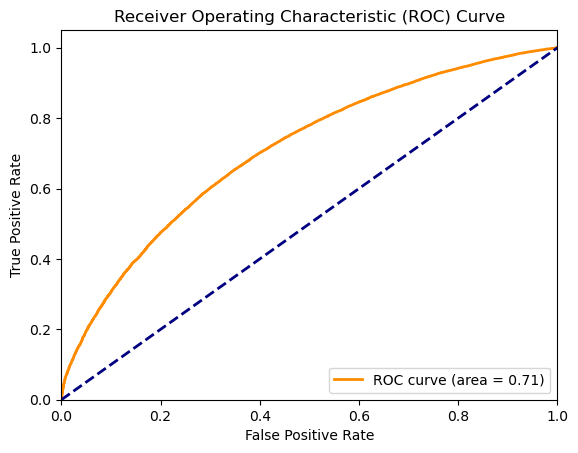

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step 1: Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test_encoded, best_model.predict_proba(X_test)[:, 1])  # Using best_model here

# Step 2: Calculate AUC
roc_auc = auc(fpr, tpr)

# Step 3: Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


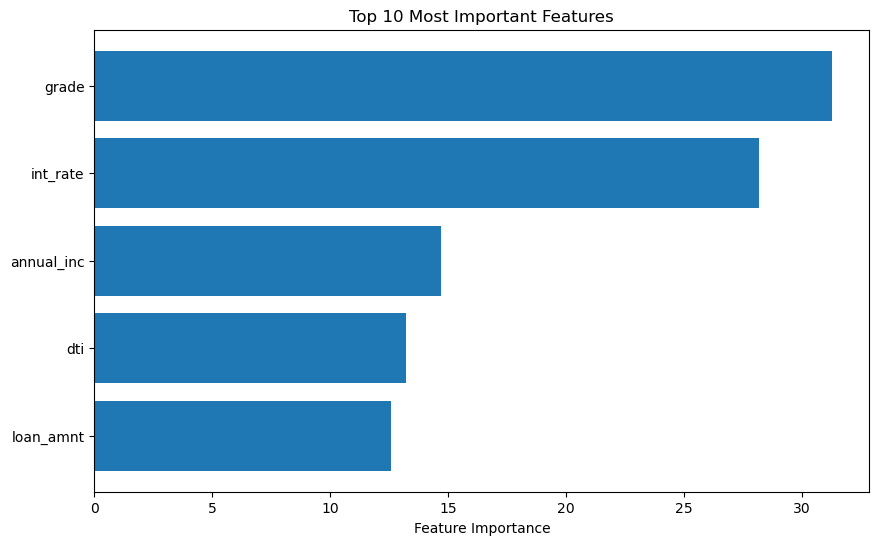

In [70]:
X_columns = X.columns  # X is the original DataFrame

# Step 1: Extract feature importance from the trained model
importances = best_model.get_feature_importance()

# Step 2: Create DataFrame for feature importance using X_columns
feature_importance = pd.DataFrame({
    'Feature': X_columns,
    'Importance': importances
})

# Step 3: Sort the features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Step 4: Plot the most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()


In [73]:
# Save the final best CatBoost model for SHAP:
best_model.save_model("catboost_model.cbm")


In [74]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [75]:
# Check data types in the original dataframe (df)
print(df.dtypes)

# Check data types in the transformed df_test
print(df_test.dtypes)


loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status               int64
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     floa

In [77]:
# Check the target column in both datasets
print(df['loan_status'].head())  # Original target column
print(df_test['PD'].head())  # Predicted target in transformed dataset


0    0
1    0
2    0
3    0
4    1
Name: loan_status, dtype: int64
0    0.460964
1    0.344849
2    0.332164
3    0.458855
4    0.615052
Name: PD, dtype: float64


In [78]:
# Check the column names in the transformed dataset
print(df_test.columns)
# Check a few rows of df_test to see if categorical columns were encoded
print(df_test.head())


Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 'PD'], dtype='object')
          0         1         2         3         4         5         6  \
0  0.191895  0.134756 -0.013454  0.191895  0.134756 -0.002582 -0.001813   
1  0.594241  0.884431 -0.964599  0.594241  0.884431 -0.573204 -0.853121   
2  1.030116  0.884431  0.797112  1.030116  0.884431  0.821118  0.704991   
3  0.080132  0.134756 -0.970581  0.080132  0.134756 -0.077775 -0.130792   
4 -0.116570 -0.614919  0.399307 -0.116570 -0.614919 -0.046547 -0.245541   

          7         8         9        PD  
0  0.036824  0.025859  0.018159  0.460964  
1  0.353122  0.525565  0.782219  0.344849  
2  1.061139  0.911067  0.782219  0.332164  
3  0.006421  0.010798  0.018159  0.458855  
4  0.013589  0.071681  0.378125  0.615052  


In [79]:
# Check the column names in the transformed dataset
print(df.columns)
# Check a few rows of df_test to see if categorical columns were encoded
print(df.head())


Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')
   loan_amnt        term  int_rate  installment grade sub_grade  \
0    10000.0   36 months     11.44       329.48     B        B4   
1     8000.0   36 months     11.99       265.68     B        B5   
2    15600.0   36 months     10.49       506.97     B        B3   
3     7200.0   36 months      6.49       220.65     A        A2   
4    24375.0   60 months     17.27       609.33     C        C5   

                 emp_title emp_length home_ownership  annual_inc  ...  \
0                Marketing  10+ years           RENT    117000.0  ...   
1       